# BirdCLEF+2026: HGNetV2-B0 Baseline [Inference]

【UPDATE】 I added a 2.5-second shifted prediction TTA, referring to [last year's 5th-place solution](https://www.kaggle.com/competitions/birdclef-2025/writeups/noir-5th-place-solution-self-distillation-is-all-y).

## About

This is a inference notebook.

If you want to see the training process, visit the training notebook:  
https://www.kaggle.com/code/ttahara/birdclef-2026-hgnetv2-b0-baseline-training

## Preparation

### libraries

In [1]:
!pip install --no-index \
    -r /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/requirements.txt \
    --find-links=/kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels

Looking in links: /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels
Processing /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels/openvino-2026.0.0-20965-cp312-cp312-manylinux_2_28_x86_64.whl (from -r /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/requirements.txt (line 1))
Processing /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels/onnxscript-0.6.2-py3-none-any.whl (from -r /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/requirements.txt (line 2))
Processing /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels/onnxsim-0.6.2-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (from -r /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/requirements.txt (line 3))
Processing /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels/onnxruntime-1.24.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (from -r /kaggle/input/notebooks/ttahara/birdclef-2

In [2]:
RANDOM_SEED = 1086

import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

In [3]:
import gc
import copy
import random
import typing as tp
from pathlib import Path

from time import time
import numpy as np
import pandas as pd

from tqdm.notebook import tqdm, trange

import soundfile

import timm
import torch
import torchaudio
from torchvision.transforms import v2 as tvt_v2

from torch import nn

from joblib import load as jb_load, Parallel, delayed
import threading

import openvino as ov

In [4]:
# # mel 前処理で PyTorch がCPUを使いすぎないようにする
# torch.set_num_threads(1)
# torch.set_num_interop_threads(1)

# os.environ["OMP_NUM_THREADS"] = "1"
# os.environ["MKL_NUM_THREADS"] = "1"

In [5]:
ROOT = Path.cwd().parent

INPUT = ROOT / "input"
DATA = INPUT / "competitions" / "birdclef-2026"
TRAIN_AUDIO = DATA / "train_audio"
TRAIN_SS = DATA / "train_soundscapes"
TEST_SS = DATA / "test_soundscapes"

# TRAINED_MODEL = INPUT / "notebooks" / "ttahara/birdclef-2026-hgnetv2-b0-baseline-training"
TRAINED_MODEL = INPUT / "notebooks" / "naganohikaru/birdclef-2026-sed-baseline-training"
# TRAINED_MODEL = Path("/kaggle/input/datasets/naganohikaru/2026-sed-model")
# TRAINED_MODEL = INPUT / "notebooks" / "naganohikaru/train-pseudo-1st-stage"
# TRAINED_MODEL = Path("/kaggle/input/datasets/naganohikaru/lse-models")

# N_FOLDS = [0] # 4
# N_CLASSES = 234

# DEBUG = True
# RANK_AVG = False

In [6]:
taxonomy = pd.read_csv(DATA / "taxonomy.csv")

CLASSES = taxonomy.primary_label.values.tolist()

label2idx = {label: idx for idx, label in enumerate(taxonomy.primary_label.values)}
idx2label = {idx: label for label, idx in label2idx.items()}

In [7]:
def set_random_seed(seed: int = 42, deterministic: bool = True):
    """Set seeds"""
    os.environ["PYTHONHASHSEED"] = str(seed)  # python
    random.seed(seed)  # python
    np.random.seed(seed)  # cpu
    torch.manual_seed(seed)  # cpu
    if torch.cuda.is_available():  # gpu
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = deterministic

set_random_seed(RANDOM_SEED)

### prepare file paths

In [8]:
# sample_sub = pd.read_csv(DATA / "sample_submission.csv")
# IS_TEST_ENV = len(sample_sub) > 10

# if IS_TEST_ENV:
#     # about 600 audio files in test environment
#     test_ss_paths = []
#     added = set()
#     for row_id in sample_sub["row_id"].values:
#         file_id = "_".join(row_id.split("_")[:-1])
#         if file_id in added:
#             continue
#         added.add(file_id)
#         test_ss_paths.append(TEST_SS / f"{file_id}.ogg")
# else:
#     if DEBUG:
#         # debug by 600 audio files in train_soundscapes 
#         test_ss_paths = sorted(TRAIN_SS.iterdir())[:600]
#     else:
#         # fast submit
#         test_ss_paths = sorted(TRAIN_SS.iterdir())[:10]

In [9]:
# test_ss_segs = []
# for p in test_ss_paths:
#     for i in range(0, 60, 5):
#         test_ss_segs.append(f"{p.stem}_{i + 5}")

In [10]:
# for row_id in test_ss_segs[:24]:
#     print(row_id)

### prepare log-mel-spectorogram transform and open vino models  

In [11]:
# class LogMelSpectrogramTransform(nn.Module):
#     def __init__(self, mel_spectrogram_params: dict, top_db: float):
#         super().__init__()
#         self.mel_transform = torchaudio.transforms.MelSpectrogram(**mel_spectrogram_params)
#         self.db = torchaudio.transforms.AmplitudeToDB(stype="power", top_db=top_db)

#     @torch.no_grad()
#     def forward(self, wave):
#         # Resizeを使わず、hop_lengthによる自然な解像度で生成
#         lms = self.db(self.mel_transform(wave)) 
        
#         # 正規化 (10秒/60秒 共通)
#         lms_min = lms.min()
#         lms_max = lms.max()
#         lms = (lms - lms_min) / (lms_max - lms_min + 1e-7)
#         return lms[:, None, :, :] # (B, 1, 256, Time)

In [12]:
# mel_spectrogram_params = dict(
#     sample_rate= 32_000,
#     n_fft      = 2048,
#     win_length = 1024,
#     hop_length = 625,  # ★ 32000 / 625 = 51.2 fps に固定,
#     f_min      = 20,
#     n_mels     = 256,
#     power      = 2.0,
#     center     = True,
#     pad_mode   = "reflect",
#     norm       = "slaney",
#     mel_scale  = "htk",
# )

# top_db = 80

# # 学習側に合わせる
# context_sec = 10.0
# target_sec = 5.0
# tta_shift_sec = target_sec / 2.0

# # 10 sec 入力で 5 sec 時と近い時間解像度を維持
# lms_shape = (256, 512)

# lms_transform = LogMelSpectrogramTransform(
#     mel_spectrogram_params,
#     top_db=top_db,
# ).eval()

In [13]:
# def compile_ov_model(ov_model_path):
#     compiled_model = ov.compile_model(
#         str(ov_model_path), "CPU", {
#             "PERFORMANCE_HINT": "THROUGHPUT",
#             "INFERENCE_NUM_THREADS": 4,
#             'NUM_STREAMS': 2}
#     )
#     return compiled_model

In [14]:
# ov_model_list = []
# for fold_id in N_FOLDS:
#     compiled_model = compile_ov_model(
#         # str(TRAINED_MODEL / f"best_model_fold{fold_id}.xml"))
#         # str(TRAINED_MODEL / f"souped_souped_best_model_fold{fold_id}.xml"))
#         str(TRAINED_MODEL / f"souped_best_model_fold{fold_id}.xml"))
#         # str(TRAINED_MODEL / f"oof_souped_model.xml"))
#     ov_model_list.append(compiled_model)
#     del compiled_model
#     # break


In [15]:
# print(f"compiled model : {len(ov_model_list)}")

## Inference

### create batchs

For TTA, I'll create two batch lists.

1. Normal batches : each data point's start_sec is `5 * i` and end_sec is `5 * (i + 1)` (`i = 0, 1, 2, ... , 11`).
2. Shifted batches: each data point's start_sec is `5 * i - 2.5` and end_sec is `5 * i + 2.5` (`i = 0, 1, 2, ..., 12`).

In [16]:
# import gc
# import numpy as np
# import torch
# from tqdm.auto import tqdm

# sample_rate = 32_000
# max_sec = 60.0
# context_sec = 20.0 # 10.0
# target_sec = 5.0
# tta_shift_sec = target_sec / 2.0

# main_target_starts = np.arange(0.0, max_sec, target_sec)  # 0,5,...,55
# shifted_target_starts = np.arange(
#     -tta_shift_sec,
#     max_sec - target_sec + tta_shift_sec + 1e-6,
#     target_sec,
# )  # -2.5, 2.5, ..., 57.5

# num_test_ss_audios = len(test_ss_paths)
# num_test_ss_segs = num_test_ss_audios * len(main_target_starts)          # 12 per file
# num_shifted_test_ss_segs = num_test_ss_audios * len(shifted_target_starts)  # 13 per file

# print(num_test_ss_segs, num_test_ss_segs / 12)
# print(num_shifted_test_ss_segs, num_shifted_test_ss_segs / 13)


# def read_fixed_60s_wave(path, sample_rate=32_000, max_sec=60.0):
#     total_len = int(sample_rate * max_sec)
#     wave = np.zeros(total_len, dtype=np.float32)

#     with soundfile.SoundFile(path) as f:
#         n_frames = min(f.frames, total_len)
#         wave[:n_frames] = f.read(frames=n_frames, dtype="float32")

#     return wave

# # read_fixed_60s_wave はそのまま残します

# def make_fcn_batch_for_one_file(path, sample_rate=32_000, max_sec=60.0):
#     """
#     1ファイルから、FCN推論用の3つの60秒波形(Main, Shift1, Shift2)を生成する
#     """
#     # 1. 60秒(1,920,000サンプル)の波形をロード
#     full_wave = read_fixed_60s_wave(path, sample_rate=sample_rate, max_sec=max_sec)

#     # 2. Main (0〜60秒): 12セグメント分
#     main_wave = full_wave.copy()

#     # 3. Shifted 1 (-2.5〜57.5秒): 最初の12個のShiftedセグメント分
#     shift_samples = int(2.5 * sample_rate) # 80,000サンプル
#     shifted_wave_1 = np.zeros_like(full_wave)
#     shifted_wave_1[shift_samples:] = full_wave[:-shift_samples]

#     # 4. Shifted 2 (57.5〜117.5秒): 13個目のShiftedセグメント分 (先頭2.5秒だけ実データ)
#     shifted_wave_2 = np.zeros_like(full_wave)
#     shifted_wave_2[:shift_samples] = full_wave[-shift_samples:]

#     # 一気に処理するためバッチ化 (3, 1920000)
#     return np.stack([main_wave, shifted_wave_1, shifted_wave_2], axis=0)


# def infer_one_fold_streaming_tta(
#     ov_model,
#     test_ss_paths,
#     gc_every=50,
# ):
#     """
#     FCN推論: 1ファイルにつき バッチサイズ3(Main, Shift1, Shift2) だけを処理する超高速版
#     """
#     main_logits = np.zeros((len(test_ss_paths) * 12, N_CLASSES), dtype=np.float32)
#     shifted_logits = np.zeros((len(test_ss_paths) * 13, N_CLASSES), dtype=np.float32)

#     input_name = ov_model.inputs[0].get_any_name()
#     output_port = ov_model.output(0)

#     main_ptr = 0
#     shifted_ptr = 0

#     for file_idx, path in enumerate(tqdm(test_ss_paths)):
#         # 1. 波形のバッチ作成 -> (3, 1920000)
#         batch_waves = make_fcn_batch_for_one_file(path, sample_rate=32_000)

#         # 2. スペクトログラム変換 (GPU) -> NumPy化 (3, 1, 256, 3073)
#         with torch.inference_mode():
#             # lms_transformはバッチ入力にそのまま対応可能です
#             batch_lms = lms_transform(torch.from_numpy(batch_waves).to("cpu"))
#         batch_lms = np.ascontiguousarray(batch_lms.cpu().numpy(), dtype=np.float32)

#         # 3. OpenVINO推論 (Batch Size = 3 で一括処理)
#         pred = ov_model({input_name: batch_lms})[output_port] # 出力形状: (3, 96, N_CLASSES)

#         # 4. NumPyで 12分割 ＆ Maxプーリング
#         # 形状を (3, 12, 8, N_CLASSES) にして、フレーム軸(axis=2)でMaxを取る -> (3, 12, N_CLASSES)
#         # pooled_pred = pred.reshape(3, 12, 8, N_CLASSES).max(axis=2)
#         pooled_pred = pred#[:, :96, :].reshape(3, 12, 8, N_CLASSES).max(axis=2)

#         # 5. 予測結果の切り出しと格納
#         main_pred = pooled_pred[0] # Mainの12セグメント
        
#         # Shiftedは Chunk1の12セグメント + Chunk2の先頭1セグメント を結合して13セグメントにする
#         shifted_pred = np.concatenate([pooled_pred[1], pooled_pred[2][:1]], axis=0) 

#         main_logits[main_ptr:main_ptr + 12] = main_pred
#         shifted_logits[shifted_ptr:shifted_ptr + 13] = shifted_pred

#         main_ptr += 12
#         shifted_ptr += 13

#         if (file_idx + 1) % gc_every == 0:
#             gc.collect()

#     return main_logits, shifted_logits

In [17]:
def init_layer(layer):
    nn.init.xavier_uniform_(layer.weight)
    if hasattr(layer, "bias") and layer.bias is not None:
        layer.bias.data.fill_(0.)

def init_bn(bn):
    bn.bias.data.fill_(0.)
    bn.weight.data.fill_(1.0)

class GeM1d(nn.Module):
    def __init__(self, p=3.0, kernel_size=3, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.kernel_size = kernel_size
        self.eps = eps
    def forward(self, x):
        x = x.clamp(min=self.eps)
        return F.avg_pool1d(x.pow(self.p), kernel_size=self.kernel_size,
                            stride=1, padding=self.kernel_size//2).pow(1.0/self.p)

class ChannelAttention(nn.Module):
    def __init__(self, dim=2048, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(dim, dim//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(dim//reduction, dim, bias=False))
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x).squeeze(-1))
        max_out = self.fc(self.max_pool(x).squeeze(-1))
        out = self.sigmoid(avg_out + max_out).unsqueeze(-1)
        return x * out

class FrequencySE(nn.Module):
    def __init__(self, n_mels=128, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d((n_mels, 1))
        self.fc = nn.Sequential(
            nn.Linear(n_mels, n_mels//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(n_mels//reduction, n_mels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, h, w = x.size()
        y = self.avg_pool(x).squeeze(-1).squeeze(1)
        y = self.fc(y).view(b, 1, h, 1)
        return x * y.expand_as(x)

class AttBlock_Topk(nn.Module):
    def __init__(self, in_features, out_features, k=3, r=1.0):
        super().__init__()
        self.att = nn.Conv1d(in_features, out_features, kernel_size=1, bias=True)
        self.cla = nn.Conv1d(in_features, out_features, kernel_size=1, bias=True)
        self.bn_att = nn.BatchNorm1d(out_features)
        init_layer(self.att)
        init_layer(self.cla)
        init_bn(self.bn_att)
        self.k = k
    def forward(self, x):
        norm_att = torch.softmax(torch.clamp(self.att(x), -10, 10), dim=-1)
        framewise = self.cla(x)
        clipwise_att = torch.sum(norm_att * framewise, dim=2)
        actual_k = min(self.k, framewise.size(-1))
        clipwise_aux = framewise.topk(actual_k, dim=2)[0].mean(dim=2)
        return clipwise_att
        
class AttBlock(nn.Module):
    def __init__(self, in_feat, out_feat):
        super().__init__()
        self.att = nn.Conv1d(in_feat, out_feat, 1, bias=True)
        self.cla = nn.Conv1d(in_feat, out_feat, 1, bias=True)
        init_layer(self.att)
        init_layer(self.cla)

    def forward(self, x):
        norm_att = torch.softmax(torch.clamp(self.att(x), -10, 10), dim=-1)
        framewise = self.cla(x)
        clipwise = torch.sum(norm_att * framewise, dim=2)
        return clipwise
        
class DistillHead(nn.Module):
    def __init__(self, backbone_dim, embed_dim=1536):
        super().__init__()
        self.proj = nn.Linear(backbone_dim, embed_dim)
        init_layer(self.proj)
    def forward(self, feat_map):
        return self.proj(feat_map.mean(dim=[2,3]))

class HgnetModel(nn.Module):
    def __init__(self, model_name, pretrained=False, drop_path_rate=0.20, drop_rate=0.20,
                 num_classes=234, head_dropout=0.5, n_mels=128):
        super().__init__()
        self.bn0 = nn.BatchNorm2d(n_mels)
        init_bn(self.bn0)
        self.backbone = timm.create_model(
            model_name, pretrained=pretrained, in_chans=1,
            global_pool="", num_classes=0,
            drop_path_rate=drop_path_rate, drop_rate=drop_rate,
        )
        with torch.no_grad():
            n_feat = self.backbone(torch.randn(1, 1, n_mels, n_mels)).shape[1]
        self.gem = GeM1d(p=3.0, kernel_size=3)
        self.fc1 = nn.Linear(n_feat, n_feat, bias=True)
        self.att_block = AttBlock_Topk(n_feat, num_classes)
        self.dropout = nn.Dropout(head_dropout)
        self.distill_head = DistillHead(n_feat, 1536)
        self.channel_att = ChannelAttention()
        self.freq_se = FrequencySE(n_mels=n_mels, reduction=16)
        init_layer(self.fc1)
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.bn0(x)
        x = x.transpose(1, 2)
        x = self.freq_se(x)
        feat = self.backbone(x)
        feat = feat.mean(dim=2)
        feat = self.channel_att(feat)
        feat = self.gem(feat)
        feat = self.dropout(feat)
        feat = feat.transpose(1, 2)
        feat = F.relu(self.fc1(feat))
        feat = feat.transpose(1, 2)
        feat = self.dropout(feat)
        clipwise = self.att_block(feat)
        return clipwise

class EffNetModel(nn.Module):
    def __init__(self, model_name, pretrained=False, drop_path_rate=0.15, drop_rate=0.2,
                 num_classes=234, head_dropout=0.35, n_mels=128):
        super().__init__()
        self.bn0 = nn.BatchNorm2d(n_mels)
        init_bn(self.bn0)
        self.backbone = timm.create_model(
            model_name, pretrained=pretrained, in_chans=1,
            global_pool="", num_classes=0,
            drop_path_rate=drop_path_rate, drop_rate=drop_rate,
        )
        with torch.no_grad():
            n_feat = self.backbone(torch.randn(1, 1, n_mels, n_mels)).shape[1]
        self.gem = GeM1d(p=3.0, kernel_size=3)
        self.fc1 = nn.Linear(n_feat, n_feat, bias=True)
        self.att_block = AttBlock(n_feat, num_classes)
        self.dropout = nn.Dropout(head_dropout)
        self.distill_head = DistillHead(n_feat, 1536)
        init_layer(self.fc1)
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.bn0(x)
        x = x.transpose(1, 2)
        feat = self.backbone(x)
        feat = feat.mean(dim=2)
        feat = self.gem(feat)
        feat = self.dropout(feat)
        feat = feat.transpose(1, 2)
        feat = F.relu(self.fc1(feat))
        feat = feat.transpose(1, 2)
        feat = self.dropout(feat)
        clipwise = self.att_block(feat)
        return clipwise

In [18]:
def load_and_prepare_audio(test_ss_paths):
    wave_list = []
    shifted_wave_list = []
    for path in tqdm(test_ss_paths, desc="Loading Audio"):
        with soundfile.SoundFile(path) as f:
            audio_data = f.read(frames=DURATION, dtype="float32")
            if audio_data.ndim > 1:
                audio_data = audio_data.mean(axis=1)
            if len(audio_data) < DURATION:
                audio_data = np.pad(audio_data, (0, DURATION - len(audio_data)))
        for seg_sec in range(0, MAX_SEC, 5):
            start = seg_sec * SAMPLE_RATE
            end = (seg_sec + 5) * SAMPLE_RATE
            wave_list.append(audio_data[start:end])
        for seg_sec in range(0, MAX_SEC - 5, 5):
            start = int((seg_sec + 2.5) * SAMPLE_RATE)
            end = int((seg_sec + 7.5) * SAMPLE_RATE)
            shifted_wave_list.append(audio_data[start:end])
    return wave_list, shifted_wave_list

In [19]:
def rank_normalize(x):
    r_x = np.zeros_like(x) 
    for i in range(x.shape[1]):
        r_x_i = pd.Series(x[:, i]).rank(method="max")
        r_x[:, i] = r_x_i / r_x_i.shape[0]
    return r_x

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [20]:
def fuse_tta(norm_by_file, shift_by_file):
    out = np.zeros_like(norm_by_file)
    out[:, 0, :] = 0.75 * norm_by_file[:, 0, :] + 0.25 * shift_by_file[:, 0, :]
    out[:, 11, :] = 0.75 * norm_by_file[:, 11, :] + 0.25 * shift_by_file[:, 10, :]
    out[:, 1:11, :] = (0.50 * norm_by_file[:, 1:11, :] + 0.25 * shift_by_file[:, 0:10, :] + 0.25 * shift_by_file[:, 1:11, :])
    return out

In [21]:
ROOT = Path.cwd().parent
INPUT = ROOT / "input"
DATA = INPUT / "competitions" / "birdclef-2026"
TEST_SS = DATA / "test_soundscapes"
sample_sub = pd.read_csv(DATA / "sample_submission.csv")
taxonomy = pd.read_csv(DATA / "taxonomy.csv")
CLASSES = taxonomy.primary_label.values.tolist()
N_CLASSES = 234
N_WINDOWS = 12
USE_ADAPT_SMOOTH = False
USE_CONTEXT_BLENDING = True
ADAPT_ALPHA = 0.20

In [22]:
N_FOLDS = 1
SAMPLE_RATE = 32_000
MAX_SEC = 60
DURATION = SAMPLE_RATE * MAX_SEC
BATCH_SIZE = 12
# RANK_AVG = False
# USE_GAUSSIAN_SMOOTH = False
# USE_PRIOR = False
# USE_CLASS_TEMP = False
# USE_FILE_SCALE = False
# USE_RANK_SCALE = False
# USE_ADAPT_SMOOTH = False

In [23]:
K = 2
IS_TEST_ENV = len(sample_sub) > 10

if IS_TEST_ENV:
    test_ss_paths = []
    added = set()
    for row_id in sample_sub["row_id"].values:
        file_id = "_".join(row_id.split("_")[:-1])
        if file_id in added:
            continue
        added.add(file_id)
        test_ss_paths.append(TEST_SS / f"{file_id}.ogg")
else:
    dry_n = K
    test_ss_paths = sorted((DATA / "train_soundscapes").iterdir())[:dry_n]
test_ss_segs = []
for p in test_ss_paths:
    for i in range(0, 60, 5):
        test_ss_segs.append(f"{p.stem}_{i+5}")
        
wave_list, shifted_wave_list = load_and_prepare_audio(test_ss_paths)
num_test_ss_audios = len(test_ss_paths)
num_test_ss_segs = len(wave_list)
num_shifted_test_ss_segs = len(shifted_wave_list)
print(f"Normal segments: {num_test_ss_segs}")
print(f"Shifted segments: {num_shifted_test_ss_segs}")

wave_batches = [np.stack(wave_list[i:i+BATCH_SIZE], axis=0)
                    for i in trange(0, len(wave_list), BATCH_SIZE, desc="Stack Normal")]
shifted_wave_batches = [np.stack(shifted_wave_list[i:i+BATCH_SIZE], axis=0)
                            for i in trange(0, len(shifted_wave_list), BATCH_SIZE, desc="Stack Shifted")]
del wave_list, shifted_wave_list
gc.collect()

Loading Audio:   0%|          | 0/2 [00:00<?, ?it/s]

Normal segments: 24
Shifted segments: 22


Stack Normal:   0%|          | 0/2 [00:00<?, ?it/s]

Stack Shifted:   0%|          | 0/2 [00:00<?, ?it/s]

46

In [24]:
MEL_PARAMS_HGNET = dict(
    sample_rate=32000, n_fft=2048, hop_length=512,
    f_min=20, f_max=16000, n_mels=128, normalized=True,
)

In [25]:
from torchvision.transforms import v2 as tvt_v2

TOP_DB = 80.0
LMS_SHAPE = (128, 313)

lms_hgnet = tvt_v2.Compose([
    torchaudio.transforms.MelSpectrogram(**MEL_PARAMS_HGNET),
    torchaudio.transforms.AmplitudeToDB(stype="power", top_db=TOP_DB),
    tvt_v2.Resize(size=LMS_SHAPE),
    lambda x: torch.clamp((x + TOP_DB) / TOP_DB, 0.0, 1.0),
    lambda x: x[:, None, :, :]
])

class TransformWrapper(nn.Module):
    def __init__(self, transform):
        super().__init__()
        self.transform = transform
    @torch.no_grad()
    def forward(self, wave):
        return self.transform(wave)
        
lms_hgnet = TransformWrapper(lms_hgnet).eval()

In [26]:
import tempfile
def ov_model_from_pt(model_class, pt_path, model_kwargs, device="CPU", input_shape=(1, 1, 128, 313)):
    model = model_class(
        **model_kwargs
    )
    m, u = model.load_state_dict(torch.load(pt_path, map_location="cpu"), strict=False)
    print(f"missing={m}")
    print(f"unexpected={u}")
    model.eval()
    
    class InferenceWrapper(nn.Module):
        def __init__(self, base_model):
            super().__init__()
            self.base_model = base_model
            
        def forward(self, x):
            clipwise = self.base_model(x)
            blended_logits = clipwise
            
            return blended_logits

    export_model = InferenceWrapper(model)
    export_model.eval()

    dummy = torch.randn(*input_shape, dtype=torch.float32)
    # with tempfile.NamedTemporaryFile(suffix=".onnx", delete=False) as f:
    #     onnx_path = f.name

    # try:
    #     torch.onnx.export(
    #         export_model, dummy, onnx_path,
    #         opset_version=17,
    #         do_constant_folding=True,
    #         input_names=["input"],
    #         output_names=["output"],
    #         dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}}
    #     )
        
    #     ov_model = ov.convert_model(onnx_path)
    # finally:
    #     os.unlink(onnx_path)

    dummy = torch.randn(*input_shape, dtype=torch.float32)
    ov_model = ov.convert_model(export_model, example_input=dummy)

    # 動的バッチサイズを設定 (ONNXの dynamic_axes と同じ効果)
    # バッチサイズ(0番目の次元)を「動的(?)」に設定
    ov_model.inputs[0].get_node().set_partial_shape(ov.PartialShape([-1, 1, 128, -1]))
    ov_model.validate_nodes_and_infer_types()

    compiled = ov.compile_model(
        ov_model, device,
        {
            "PERFORMANCE_HINT": "THROUGHPUT",
            "INFERENCE_NUM_THREADS": 4,
            "NUM_STREAMS": 2,
        }
    )
    return compiled


In [27]:
hgnet_kwargs = dict(
        model_name="hgnetv2_b0.ssld_stage2_ft_in1k",
        pretrained=False, drop_path_rate=0.15, drop_rate=0.20,
        num_classes=N_CLASSES, head_dropout=0.5, n_mels=128,
)

In [28]:
def infer_stream(engine, wave_batches, lms_transform, num_segments, num_classes):
    logits = np.zeros((num_segments, num_classes), dtype=np.float32)
    infer_queue = ov.AsyncInferQueue(engine, 16)
    input_name = engine.inputs[0].get_any_name()
    def callback(request, userdata):
        logits[userdata] = request.get_output_tensor().data
    infer_queue.set_callback(callback)
    total = 0
    for waves in tqdm(wave_batches, desc="Inference"):
        bsize = len(waves)
        idxs = np.arange(total, total + bsize)
        total += bsize
        lms = lms_transform(torch.from_numpy(waves)).numpy().astype(np.float32)
        infer_queue.start_async({input_name: lms}, userdata=idxs)
    infer_queue.wait_all()
    return logits

In [29]:
import torch.nn.functional as F

HGNET_PATH_A = TRAINED_MODEL / f"souped_best_model_fold0.pt"

engine_hgnet_A = ov_model_from_pt(HgnetModel, HGNET_PATH_A, hgnet_kwargs)

logits_h_norm_A = infer_stream(engine_hgnet_A, wave_batches, lms_hgnet, num_test_ss_segs, N_CLASSES)
logits_h_shift_A = infer_stream(engine_hgnet_A, shifted_wave_batches, lms_hgnet, num_shifted_test_ss_segs, N_CLASSES)


missing=[]
unexpected=[]


/tmp/ipykernel_57/4074415781.py:67: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  actual_k = min(self.k, framewise.size(-1))


Inference:   0%|          | 0/2 [00:00<?, ?it/s]

Inference:   0%|          | 0/2 [00:00<?, ?it/s]

In [30]:
pred_h_norm_A = sigmoid(logits_h_norm_A).reshape(num_test_ss_audios, 12, N_CLASSES)
pred_h_shift_A = sigmoid(logits_h_shift_A).reshape(num_test_ss_audios, 11, N_CLASSES)
tta_h_cross1 = fuse_tta(pred_h_norm_A, pred_h_shift_A)
final_h = tta_h_cross1
final_h_flat = final_h.reshape(num_test_ss_segs, N_CLASSES)

In [31]:
# 平滑函数 (5th 2025)
def temporal_smooth_on_probs(probs, alpha=0.1):
    N, C = probs.shape
    n_files = N // 12
    probs_reshaped = probs.reshape(n_files, 12, C)
    smoothed = probs_reshaped.copy()
    for i in range(1, 11):
        smoothed[:, i, :] = (alpha * probs_reshaped[:, i-1, :] +
                             (1-2*alpha) * probs_reshaped[:, i, :] +
                             alpha * probs_reshaped[:, i+1, :])
    smoothed[:, 0, :] = (1-alpha) * probs_reshaped[:, 0, :] + alpha * probs_reshaped[:, 1, :]
    smoothed[:, 11, :] = (1-alpha) * probs_reshaped[:, 11, :] + alpha * probs_reshaped[:, 10, :]
    return smoothed.reshape(N, C)

# --- ★追加部分：ファイル全体の文脈加味 ---
def clip_level_context_blending(probs, n_windows=12, weight_current=0.85):
    """
    B. ファイル全体の文脈加味 (Clip-level Context Blending)
    各ファイル内（12ウィンドウ）での各クラスの最大確率をベースラインとしてブレンドする。
    """
    N, C = probs.shape
    
    # (全セグメント, クラス数) -> (ファイル数, 12ウィンドウ, クラス数) に変形
    view = probs.reshape(-1, n_windows, C)
    
    # 各ファイル内（axis=1）での各鳥の最大確率を計算 -> Shape: (ファイル数, 1, クラス数)
    file_max = view.max(axis=1, keepdims=True)
    
    # ブレンド (Numpyのブロードキャストにより一括計算)
    blended = view * weight_current + file_max * (1.0 - weight_current)
    
    # 元の (全セグメント, クラス数) の形状に戻して返す
    return blended.reshape(N, C)

# final_h_flat = temporal_smooth_on_probs(final_h_flat, alpha=0.1)

# 1. TTA後の予測値に対して、まずファイル全体の文脈（Clip-level Context）を加味する
final_h_flat = clip_level_context_blending(final_h_flat, n_windows=12, weight_current=0.85)

# 2. その後、時間方向の平滑化（Temporal Smoothing）を適用してノイズを消す
final_h_flat = temporal_smooth_on_probs(final_h_flat, alpha=0.1)

# 3. 確率が1.0を超えないように念のためクリップ
final_h_flat = np.clip(final_h_flat, 0.0, 1.0)

In [32]:
hg_df = pd.DataFrame(final_h_flat, columns=CLASSES)

In [33]:
sub_df = pd.DataFrame(
    final_h_flat,
    columns=CLASSES, 
    index=pd.Series(test_ss_segs, name="row_id"),
).reset_index()

display(sub_df.head())

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Train_0001_S08_20250606_030007_5,0.036231,0.234384,0.002026,0.004362,0.008841,0.001021,0.000453,0.001232,0.000164,...,0.000590,0.009659,0.001869,0.000599,0.000311,0.004047,0.002099,0.001790,0.000489,0.003138
1,BC2026_Train_0001_S08_20250606_030007_10,0.040783,0.218997,0.001699,0.003682,0.008738,0.000811,0.000398,0.001263,0.000135,...,0.000532,0.009341,0.001781,0.000544,0.000250,0.003690,0.001778,0.001680,0.000453,0.003004
2,BC2026_Train_0001_S08_20250606_030007_15,0.057211,0.188708,0.001323,0.003481,0.007329,0.000646,0.000272,0.001016,0.000111,...,0.000467,0.008144,0.001517,0.000482,0.000231,0.003256,0.001533,0.001640,0.000451,0.003162
3,BC2026_Train_0001_S08_20250606_030007_20,0.100830,0.195860,0.001486,0.003274,0.009029,0.000813,0.000305,0.001132,0.000135,...,0.000514,0.009511,0.001505,0.000625,0.000307,0.003810,0.001843,0.001903,0.000538,0.003704
4,BC2026_Train_0001_S08_20250606_030007_25,0.046668,0.222024,0.001763,0.003872,0.008899,0.000914,0.000406,0.001170,0.000214,...,0.000581,0.010508,0.001864,0.000549,0.000301,0.004322,0.002055,0.001949,0.000532,0.003252


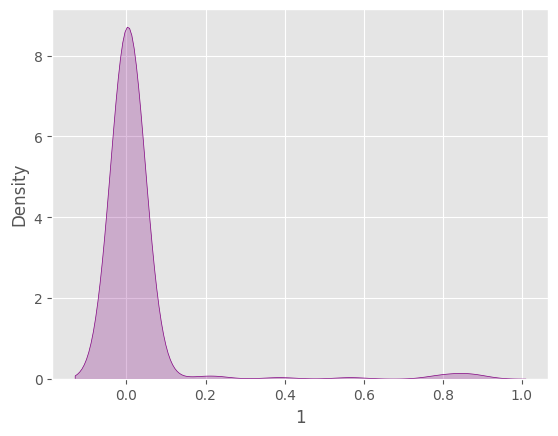

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('ggplot')

# 描画
sns.kdeplot(sub_df.iloc[1, 1:], fill=True, color='purple')
plt.show()

In [35]:
sub_df = pd.merge(
    sample_sub[["row_id"]], sub_df.iloc[:, :-1],
    on="row_id", how="left")

sub_df.to_csv("submission.csv", index=False)
print(sub_df.shape)
display(sub_df.head())

(3, 234)


,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whlspi1,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1
0,BC2026_Test_0001_S05_20250227_010002_5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BC2026_Test_0001_S05_20250227_010002_10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BC2026_Test_0001_S05_20250227_010002_15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## EOF